# Dual Decoder

In [1]:
import pandas as pd
from pathlib import Path
import os

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config
#from InterScale.pl.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_parameter_space

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pi

## 0. Load paths

In [3]:
BASE_DIR_PROJECT = "/lustre/groups/ml01/workspace/sara.jimenez/InterScale/"

In [39]:
CFG_DUAL_LEGNINI = os.path.join(BASE_DIR_PROJECT, "configs/legnini23_regr_node_DualCombined_genes.yaml")
#CFG_DUAL_MELTON = os.path.join(BASE_DIR_REPO, "GT-long-range-niches/src/config_files/melton25/regr_dual_combined.yaml")

In [40]:
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## 1. Load trained model

In [41]:
cfg = load_config(CFG_DUAL_LEGNINI)
cfg

CfgNode({'wandb': CfgNode({'use': True, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 4299, 'long_range_attention': False, 'type_gex_embedding': 'PCA'})}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'cpu', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'SmoothL1', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/202

In [42]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [43]:
import numpy as np
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [44]:
model_name = "legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model"

In [46]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = cfg.dataset.prediction_task, 
    layer_key = cfg.dataset.layer_key, 
    sample_key_list = cfg.dataset.sample_key, 
    prediction_obs =  cfg.dataset.prediction_obs, 
    group_key = cfg.dataset.group_label, 
    view_registry = False
)

dual_combined_model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR, "legnini23/model_dual_decoder"), 
    adata, 
    cfg,
    model_name="dual_legnini23_regr_node_44_GCN_self-attn-transformer_model",
    local_component = True, 
    global_component = True, 
)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from /lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [47]:
print(dual_combined_model)

## 2. Evaluation

In [48]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .layers/log1p_norm


In [49]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

In [50]:
local_decoder_weight = dual_combined_model.module.state_dict()['local_module.decoder.decoder.weight']
global_decoder_weight = dual_combined_model.module.state_dict()['global_module.decoder.decoder.weight']

In [51]:
global_decoder_weight

tensor([[ 0.1722,  0.1084,  0.0729,  ...,  0.1233,  0.0066, -0.1029],
        [ 0.0995, -0.0470, -0.0954,  ...,  0.2306, -0.0557, -0.1082],
        [ 0.0286,  0.0800,  0.1262,  ..., -0.2073, -0.1320, -0.1285],
        ...,
        [ 0.2415,  0.1290, -0.0601,  ...,  0.2138, -0.0658, -0.0526],
        [-0.2035,  0.1444,  0.0788,  ...,  0.2371,  0.0342,  0.0691],
        [ 0.2385, -0.0262,  0.1579,  ..., -0.1562, -0.2097, -0.0357]])

In [52]:
local_decoder_weight

tensor([[-0.0184,  0.2268, -0.1315,  ..., -0.2245, -0.0367,  0.0781],
        [-0.2424,  0.0856, -0.1203,  ...,  0.1674,  0.1542, -0.0708],
        [ 0.0076,  0.0575, -0.1571,  ...,  0.1512,  0.1995, -0.2399],
        ...,
        [-0.1363, -0.1333, -0.1820,  ...,  0.1367,  0.0405,  0.1415],
        [-0.1480,  0.0862,  0.1163,  ..., -0.2177,  0.0044,  0.1324],
        [-0.2314, -0.0043,  0.1751,  ..., -0.0906,  0.1978,  0.0890]])

In [53]:
decoder_weight

NameError: name 'decoder_weight' is not defined

In [54]:
import numpy as np
np.unique(result.obs['condition'])

array(['Ctrl', 'SHH'], dtype=object)

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for _y_pred_local model:
      gene        r2    r2_log  r2_rank
24  FOSL2  0.008577  0.008541     88.0
74   SIX6 -0.000782 -0.000782     87.0
60  OLIG1 -0.001023 -0.001024     86.0
86  FOXG1 -0.003052 -0.003057     85.0
73    SHH -0.003447 -0.003453     84.0


/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for _y_pred_global model:
      gene        r2    r2_log  r2_rank
62    OTP  0.016818  0.016678     88.0
5     ARC -0.005619 -0.005635     87.0
40   ISL1 -0.008265 -0.008300     86.0
86  FOXG1 -0.025968 -0.026311     85.0
49   MSX2 -0.027998 -0.028397     84.0


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


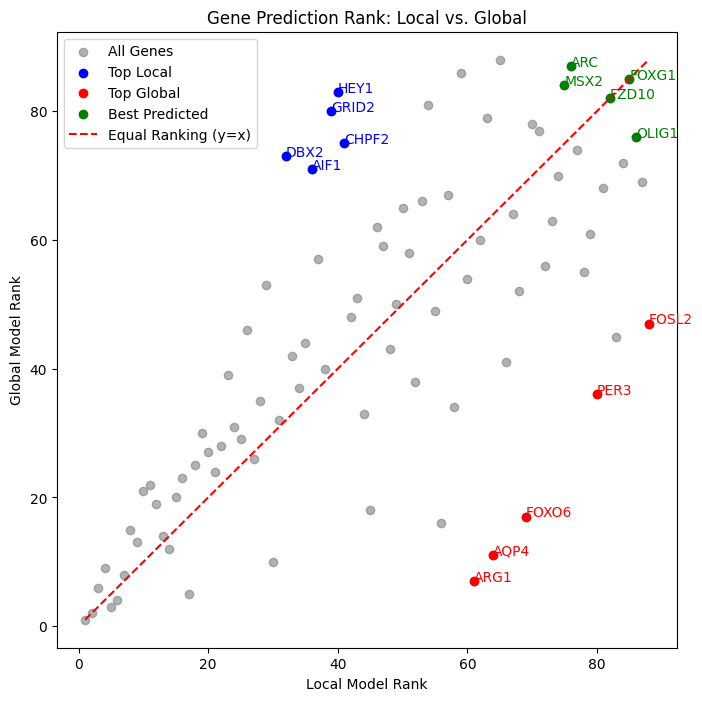

(     gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 35   HEY1        40.0         83.0            -43.0      61.5
 18   DBX2        32.0         73.0            -41.0      52.5
 33  GRID2        39.0         80.0            -41.0      59.5
 2    AIF1        36.0         71.0            -35.0      53.5
 12  CHPF2        41.0         75.0            -34.0      58.0,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 6    ARG1        61.0          7.0             54.0      34.0
 4    AQP4        64.0         11.0             53.0      37.5
 27  FOXO6        69.0         17.0             52.0      43.0
 67   PER3        80.0         36.0             44.0      58.0
 24  FOSL2        88.0         47.0             41.0      67.5,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 86  FOXG1        85.0         85.0              0.0      85.0
 28  FZD10        82.0         82.0              0.0      82.0
 5     ARC        76.0         87.0            -11.0 

In [55]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(result[result.obs['condition'] =='SHH'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for _y_pred_local model:
       gene        r2    r2_log  r2_rank
53  NKX2.1  0.000000  0.000000     87.5
87   TREM2  0.000000  0.000000     87.5
38   HPRT1 -0.001383 -0.001384     86.0
67    PER3 -0.007003 -0.007028     85.0
20   EOMES -0.009359 -0.009403     84.0


/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for _y_pred_global model:
       gene        r2    r2_log  r2_rank
53  NKX2.1  0.000000  0.000000     87.5
87   TREM2  0.000000  0.000000     87.5
33   GRID2 -0.000668 -0.000668     86.0
25   FOXA1 -0.005331 -0.005345     85.0
20   EOMES -0.007598 -0.007627     84.0


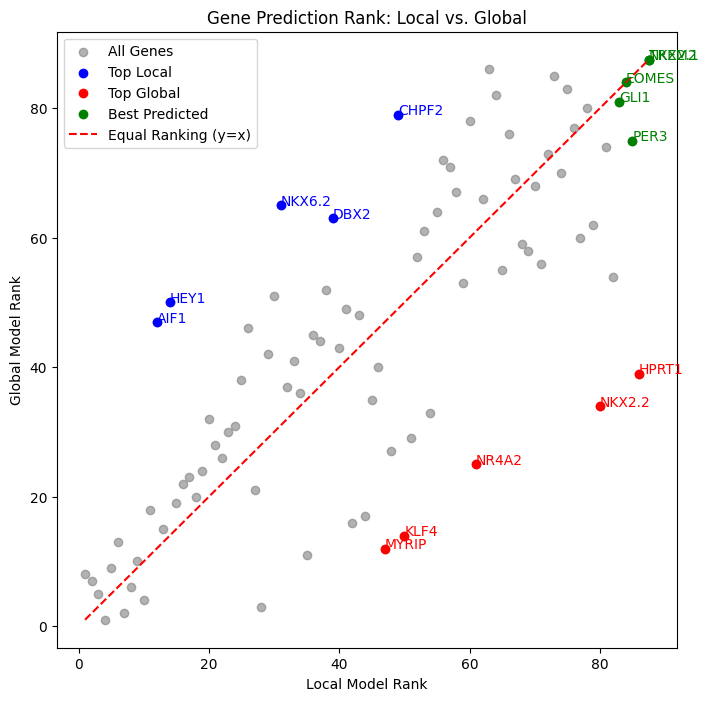

(      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 35    HEY1        14.0         50.0            -36.0      32.0
 2     AIF1        12.0         47.0            -35.0      29.5
 56  NKX6.2        31.0         65.0            -34.0      48.0
 12   CHPF2        49.0         79.0            -30.0      64.0
 18    DBX2        39.0         63.0            -24.0      51.0,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 38   HPRT1        86.0         39.0             47.0      62.5
 54  NKX2.2        80.0         34.0             46.0      57.0
 44    KLF4        50.0         14.0             36.0      32.0
 57   NR4A2        61.0         25.0             36.0      43.0
 50   MYRIP        47.0         12.0             35.0      29.5,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 53  NKX2.1        87.5         87.5              0.0      87.5
 87   TREM2        87.5         87.5              0.0      87.5
 20   EOMES        84.0         84.0  

In [56]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(result[result.obs['condition'] =='Ctrl'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)